# Compreensão dos Dados

**Projeto:** Projeto ANEEL - Energia em Risco: Análise de Dados de Continuidade Elétrica e Previsão de Risco Regulatório (ANEEL)  

**Metodologia:** CRISP-DM

**Período de Análise:** 2021 – 2025

---

## Visão Geral

Este notebook faz parte da **Fase 2 do CRISP-DM - Compreensão dos Dados (Data Understanding)**. O objetivo é desenvolver um inventário das camadas `raw`, `interim` e `processed`, analisar as tabelas fato e dimensões, documentar colunas, tipos, chaves e granularidades, mapear as entidades por domínio de negócio, apresentar os modelos conceitual e físico do Star Schema e sintetizar os dados disponíveis para Machine Learning.

---

## Sumário

1. Configurações do ambiente  
2. Camadas e Fluxo de Dados  
3. Inventário dos Datasets  
4. Tabelas fato e dimensão  
5. Dicionário das colunas  
6. Granularidade, chaves e cardinalidade
7. Domínios de negócio  
8. Modelo Conceitual  
9. Star Schema  
10. Dados disponíveis para modelagem

---

## 1. Configurações do ambiente

In [116]:
# Importações
import sys
from pathlib import Path

import duckdb
import pandas as pd
from IPython.display import display, Markdown, HTML

# Configurações de diretórios
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import CONT_PATH, INT_PATH, LIM_PATH, ATR_PATH, REG_PATH, RAW_DIR, INTERIM_DIR, PROCESSED_DIR
from src.data.constants import ANO_INICIO, ANO_FIM

# Configurações de visualização
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", lambda value: f"{value:.2f}")

# Conexão DuckDB
con = duckdb.connect()

---

## 2. Camadas e fluxo de dados


O projeto organiza os dados em três camadas principais. Cada camada possui uma finalidade específica e representa um estágio diferente de maturidade dos dados. 

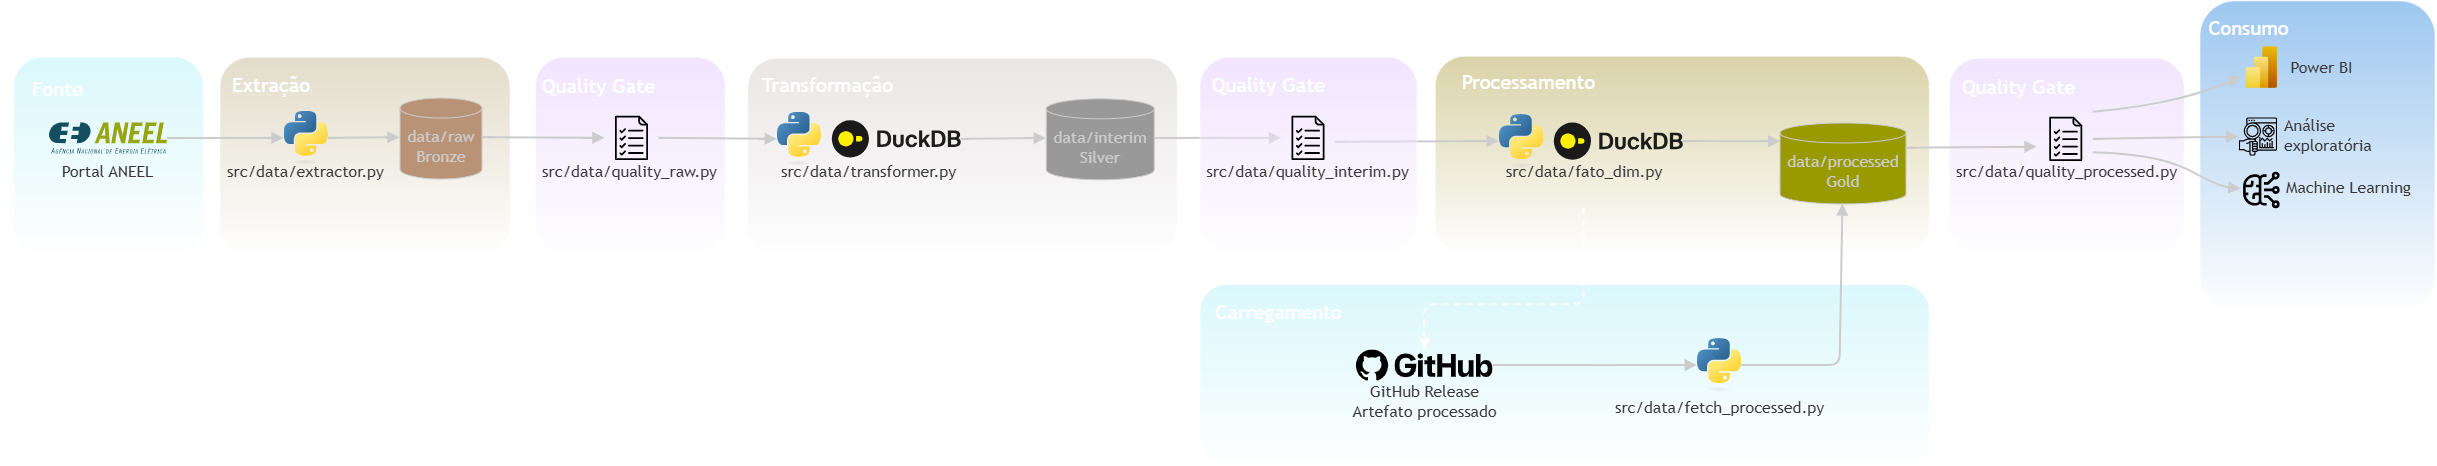

In [117]:
# Diagrama de Arquitetura do Projeto
architecture_diagram = PROJECT_ROOT / "docs" / "assets" / "architecture_diagram.png"

display(
    Image(
        filename=str(architecture_diagram),
        width=2400,
    )
)

- **Raw:** arquivos baixados diretamente do Portal de Dados Abertos da ANEEL.
- **Interim:** dados tratados com DuckDB e SQL, com nomes, tipos, chaves e filtros padronizados.
- **Processed:** tabelas fato e dimensões do Star Schema, destinadas ao consumo analítico.

Os quality gates validam cada transição antes que os dados avancem para a camada seguinte com o propósito de garantir a integridade e confiabilidade dos dados processados.

In [118]:
# Camadas de dados e responsabilidades do pipeline
camadas = pd.DataFrame([
    {
        "pasta": "raw",
        "camada": "Bronze",
        "finalidade": "Preservar os dados recebidos das fontes oficiais do portal da ANEEL",
        "formato(s)": "Parquet e CSV",
        "processamento": "extractor.py",
        "destino": "Quality Gate Raw",
    },
    {
        "pasta": "interim",
        "camada": "Silver",
        "finalidade": "Filtrar, padronizar e preparar os dados para a modelagem",
        "formato(s)": "Parquet",
        "processamento": "transformer.py + filter_*.sql",
        "destino": "Quality Gate Interim",
    },
    {
        "pasta": "processed",
        "camada": "Gold",
        "finalidade": "Disponibilizar o modelo dimensional para consumo analítico",
        "formato(s)": "Parquet",
        "processamento": "fato_dim.py + SQL dimensional",
        "destino": "Power BI, EDA e Machine Learning",
    },
])


display(
    camadas.style.set_properties(        
        **{"white-space": "normal", "min-width": "100px"},
    )
)

,pasta,camada,finalidade,formato(s),processamento,destino
0,raw,Bronze,Preservar os dados recebidos das fontes oficiais do portal da ANEEL,Parquet e CSV,extractor.py,Quality Gate Raw
1,interim,Silver,"Filtrar, padronizar e preparar os dados para a modelagem",Parquet,transformer.py + filter_*.sql,Quality Gate Interim
2,processed,Gold,Disponibilizar o modelo dimensional para consumo analítico,Parquet,fato_dim.py + SQL dimensional,"Power BI, EDA e Machine Learning"


---

## 3. Inventário dos datasets

Esta seção identifica os arquivos disponíveis em cada camada e resume sua volumetria.

In [119]:
# Inventário dos arquivos na camada raw

RAW_FILES = {
    "raw": RAW_DIR,
}

inventory_rows = []
for layer, directory in RAW_FILES.items():
    files = sorted(path for path in directory.iterdir() if path.is_file() and path.name != ".gitkeep") if directory.exists() else []
    for path in files:
        suffix = path.suffix.lower()
        if suffix == ".parquet":
            relation = "read_parquet(?)"
            parameters = [str(path)]
        elif suffix == ".csv":
            relation = "read_csv_auto(?, all_varchar=true, ignore_errors=true)"
            parameters = [str(path)]
        else:
            continue

        row_count = int(con.execute(f"SELECT COUNT(*) FROM {relation}", parameters).fetchone()[0])
        column_count = len(con.execute(f"DESCRIBE SELECT * FROM {relation}", parameters).fetchall())
        inventory_rows.append({
            "camada": layer,
            "arquivo": path.name,
            "formato": suffix.removeprefix("."),
            "linhas": row_count,
            "colunas": column_count,
            "tamanho_mb": path.stat().st_size / (1024 * 1024),
        })

df_raw_inventory = pd.DataFrame(inventory_rows)
display(df_raw_inventory)

df_raw_inventory.to_csv(
    REFERENCES_DIR / "raw_inventory.csv",
    index=False,
)

,camada,arquivo,formato,linhas,colunas,tamanho_mb
0,raw,raw_atributos.csv,csv,776216,9,69.40
1,raw,raw_continuidade.parquet,parquet,5108332,9,28.80
2,raw,raw_interrupcoes_2021.parquet,parquet,7810670,18,202.98
3,raw,raw_interrupcoes_2022.parquet,parquet,8495616,18,218.72
4,raw,raw_interrupcoes_2023.parquet,parquet,9177911,18,234.65
5,raw,raw_interrupcoes_2024.parquet,parquet,9211251,18,242.56
6,raw,raw_interrupcoes_2025.parquet,parquet,9715372,18,259.88
7,raw,raw_limites.csv,csv,263401,8,24.67
8,raw,raw_regiao.csv,csv,42699,5,2.08


In [120]:
# Inventário dos arquivos na camada interim

INTERIM_FILES = {
    "interim": INTERIM_DIR,
}

inventory_rows = []
for layer, directory in INTERIM_FILES.items():
    files = sorted(path for path in directory.iterdir() if path.is_file() and path.name != ".gitkeep") if directory.exists() else []
    for path in files:
        suffix = path.suffix.lower()
        if suffix == ".parquet":
            relation = "read_parquet(?)"
            parameters = [str(path)]
        else:
            continue

        row_count = int(con.execute(f"SELECT COUNT(*) FROM {relation}", parameters).fetchone()[0])
        column_count = len(con.execute(f"DESCRIBE SELECT * FROM {relation}", parameters).fetchall())
        inventory_rows.append({
            "camada": layer,
            "arquivo": path.name,
            "formato": suffix.removeprefix("."),
            "linhas": row_count,
            "colunas": column_count,
            "tamanho_mb": path.stat().st_size / (1024 * 1024),
        })

df_interim_inventory = pd.DataFrame(inventory_rows)
display(df_interim_inventory)

df_interim_inventory.to_csv(
    REFERENCES_DIR / "interim_inventory.csv",
    index=False,
)

,camada,arquivo,formato,linhas,colunas,tamanho_mb
0,interim,atributos.parquet,parquet,7569,9,0.10
1,interim,continuidade_2021_2025.parquet,parquet,375082,8,2.48
2,interim,interrupcoes_2021_2025.parquet,parquet,44410820,15,694.11
3,interim,limites_2021_2025.parquet,parquet,31844,6,0.10
4,interim,regiao.parquet,parquet,15162,5,0.15


In [121]:
# Inventário dos arquivos na camada processed

PROCESSED_FILES = {
    "processed": PROCESSED_DIR,
}

inventory_rows = []
for layer, directory in PROCESSED_FILES.items():
    files = sorted(path for path in directory.iterdir() if path.is_file() and path.name != ".gitkeep") if directory.exists() else []
    for path in files:
        suffix = path.suffix.lower()
        if suffix == ".parquet":
            relation = "read_parquet(?)"
            parameters = [str(path)]
        else:
            continue

        row_count = int(con.execute(f"SELECT COUNT(*) FROM {relation}", parameters).fetchone()[0])
        column_count = len(con.execute(f"DESCRIBE SELECT * FROM {relation}", parameters).fetchall())
        inventory_rows.append({
            "camada": layer,
            "arquivo": path.name,
            "formato": suffix.removeprefix("."),
            "linhas": row_count,
            "colunas": column_count,
            "tamanho_mb": path.stat().st_size / (1024 * 1024),
        })

df_processed_inventory = pd.DataFrame(inventory_rows)
display(df_processed_inventory)

df_processed_inventory.to_csv(
    REFERENCES_DIR / "processed_inventory.csv",
    index=False,
)

,camada,arquivo,formato,linhas,colunas,tamanho_mb
0,processed,dim_causa_interrupcao.parquet,parquet,518,5,0.01
1,processed,dim_conjunto.parquet,parquet,3824,9,0.06
2,processed,dim_data.parquet,parquet,1826,7,0.01
3,processed,dim_distribuidora.parquet,parquet,105,3,0.00
4,processed,dim_indicador.parquet,parquet,2,4,0.00
5,processed,dim_motivo_interrupcao.parquet,parquet,9,4,0.00
6,processed,dim_tipo_interrupcao.parquet,parquet,2,2,0.00
7,processed,fato_causa_mensal.parquet,parquet,3002279,16,87.62
8,processed,fato_continuidade.parquet,parquet,375082,10,5.32


---

## 4. Tabelas fato e dimensões

A camada `processed` implementa o modelo dimensional. As **dimensões** armazenam o contexto descritivo usado para filtrar e segmentar as análises. As **tabelas fato** armazenam eventos ou métricas mensuráveis em uma granularidade definida.

In [122]:
# Classificação das tabelas da camada processed
star_schema = pd.DataFrame([
    ["dim_data", "Dimensão", "Calendário diário do período analisado"],
    ["dim_distribuidora", "Dimensão", "Distribuidoras e seus identificadores"],
    ["dim_conjunto", "Dimensão", "Conjuntos elétricos e localização"],
    ["dim_indicador", "Dimensão", "Indicadores DEC e FEC"],
    ["dim_tipo_interrupcao", "Dimensão", "Tipos operacionais de interrupção"],
    ["dim_motivo_interrupcao", "Dimensão", "Motivos regulatórios de interrupção"],
    ["dim_causa_interrupcao", "Dimensão", "Causas normalizadas de interrupção"],
    ["fato_continuidade", "Fato", "Valores apurados e limites de DEC/FEC"],
    ["fato_causa_mensal", "Fato", "Interrupções agregadas e contribuições estimadas"],
], columns=["tabela", "tipo", "finalidade"])

display(star_schema)

,tabela,tipo,finalidade
0,dim_data,Dimensão,Calendário diário do período analisado
1,dim_distribuidora,Dimensão,Distribuidoras e seus identificadores
2,dim_conjunto,Dimensão,Conjuntos elétricos e localização
3,dim_indicador,Dimensão,Indicadores DEC e FEC
4,dim_tipo_interrupcao,Dimensão,Tipos operacionais de interrupção
5,dim_motivo_interrupcao,Dimensão,Motivos regulatórios de interrupção
6,dim_causa_interrupcao,Dimensão,Causas normalizadas de interrupção
7,fato_continuidade,Fato,Valores apurados e limites de DEC/FEC
8,fato_causa_mensal,Fato,Interrupções agregadas e contribuições estimadas


---

## 5. Dicionário de Dados

O dicionário abaixo descreve o schema físico das tabelas da camada `processed`. A classificação diferencia chaves primárias, chaves estrangeiras, tipos e atributos descritivos. 

In [123]:
# Dicionário físico das colunas da camada processed
REFERENCES_DIR = PROJECT_ROOT / "references"

KEY_COLUMNS = {
    "dim_data": {"DataKey": "PK"},
    "dim_distribuidora": {"DistribuidoraKey": "PK"},
    "dim_conjunto": {"ConjuntoKey": "PK", "DistribuidoraKey": "FK"},
    "dim_indicador": {"IndicadorKey": "PK"},
    "dim_tipo_interrupcao": {"TipoInterrupcaoKey": "PK"},
    "dim_motivo_interrupcao": {"MotivoInterrupcaoKey": "PK"},
    "dim_causa_interrupcao": {"CausaKey": "PK"},
    "fato_continuidade": {
        "FatoContinuidadeKey": "PK", "DataKey": "FK", "DistribuidoraKey": "FK",
        "ConjuntoKey": "FK", "IndicadorKey": "FK",
    },
    "fato_causa_mensal": {
        "FatoCausaMensalKey": "PK", "DataKey": "FK", "DistribuidoraKey": "FK",
        "ConjuntoKey": "FK", "TipoInterrupcaoKey": "FK", "MotivoInterrupcaoKey": "FK",
        "CausaKey": "FK",
    },
}

DESCRIPTIVE_COLUMNS = {"Data", "MesNome", "AnoMes", "Trimestre", "SigAgente", "NumCNPJ", "DscConjunto", "Municipio", "UF", "Regiao", "SigIndicador", "NomeIndicador", "Unidade", "TipoInterrupcao", "MotivoDescricao", "Origem", "Programacao", "GrupoCausa", "CausaDetalhada"}

column_rows = []
for table_name in star_schema["tabela"]:
    table_path = PROCESSED_DIR / f"{table_name}.parquet"
    schema = con.execute("DESCRIBE SELECT * FROM read_parquet(?)", [str(table_path)]).fetchall()
    for column_name, data_type, *_ in schema:
        key_role = KEY_COLUMNS.get(table_name, {}).get(column_name, "")
        if key_role:
            column_role = "Chave"
        elif column_name in DESCRIPTIVE_COLUMNS:
            column_role = "Atributo descritivo"
        elif table_name.startswith("fato_"):
            column_role = "Métrica"
        else:
            column_role = "Atributo"
        column_rows.append({
            "tabela": table_name,
            "coluna": column_name,
            "tipo": data_type,
            "papel": column_role,
            "tipo_chave": key_role or "-",
            
        })

df_dicionario = pd.DataFrame(column_rows)
display(df_dicionario)
df_dicionario.to_csv(
    REFERENCES_DIR / "dictionary_processed.csv",
    index=False,
)

,tabela,coluna,tipo,papel,tipo_chave
0,dim_data,DataKey,INTEGER,Chave,PK
1,dim_data,Data,DATE,Atributo descritivo,-
2,dim_data,Ano,SMALLINT,Atributo,-
3,dim_data,MesNumero,TINYINT,Atributo,-
4,dim_data,MesNome,VARCHAR,Atributo descritivo,-
5,dim_data,AnoMes,VARCHAR,Atributo descritivo,-
6,dim_data,Trimestre,VARCHAR,Atributo descritivo,-
7,dim_distribuidora,SigAgente,VARCHAR,Atributo descritivo,-
8,dim_distribuidora,NumCNPJ,VARCHAR,Atributo descritivo,-
9,dim_distribuidora,DistribuidoraKey,BIGINT,Chave,PK


---

## 6. Granularidade, relacionamentos e cardinalidade

Nesta seção são apresentadas a granularidade, relacionamento e cardinalidade das tabelas. A granularidade define o que representa cada linha de uma tabela. As chaves identificam os registros e estabelecem os relacionamentos entre fatos e dimensões. A tabela também apresenta o tipo, a cardinalidade e a interpretação de cada relação.

In [124]:
# Granularidade, chaves, tipos, cardinalidades e interpretações por tabela
relationship_rows = [
    ["dim_distribuidora", "dim_conjunto", "1:N", "Uma distribuidora atende vários conjuntos"],
    ["dim_data", "fato_continuidade", "1:N", "Um dia pode possuir várias medições"],
    ["dim_distribuidora", "fato_continuidade", "1:N", "Uma distribuidora possui várias medições"],
    ["dim_conjunto", "fato_continuidade", "1:N", "Um conjunto possui várias medições mensais"],
    ["dim_indicador", "fato_continuidade", "1:N", "Um indicador aparece em várias medições"],
    ["dim_data", "fato_causa_mensal", "1:N", "Um período pode possuir várias agregações"],
    ["dim_distribuidora", "fato_causa_mensal", "1:N", "Uma distribuidora possui várias agregações"],
    ["dim_conjunto", "fato_causa_mensal", "1:N", "Um conjunto possui várias agregações"],
    ["dim_tipo_interrupcao", "fato_causa_mensal", "1:N", "Um tipo classifica várias agregações"],
    ["dim_motivo_interrupcao", "fato_causa_mensal", "1:N", "Um motivo aparece em várias agregações"],
    ["dim_causa_interrupcao", "fato_causa_mensal", "1:N", "Uma causa aparece em várias agregações"],
]

relationship_map = {}
for origin, destination, cardinality, interpretation in relationship_rows:
    relationship_map.setdefault(origin, []).append((cardinality, interpretation))
    relationship_map.setdefault(destination, []).append((cardinality, interpretation))

summary_rows = []
for table_name in star_schema["tabela"]:
    table_columns = df_dicionario[df_dicionario["tabela"] == table_name]
    key_column = "tipo_chave" if "tipo_chave" in table_columns.columns else "chave"
    primary_keys = table_columns.loc[table_columns[key_column] == "PK", "coluna"].tolist()
    foreign_keys = table_columns.loc[table_columns[key_column] == "FK", "coluna"].tolist()
    context = star_schema.loc[star_schema["tabela"] == table_name, "finalidade"].iloc[0]
    table_relationships = relationship_map.get(table_name, [])
    summary_rows.append({
        "tabela": table_name,
        "granularidade_contexto": context,
        "chave_primaria (PK)": ", ".join(primary_keys) or "-",
        "chave_estrangeira (FK)": ", ".join(foreign_keys) or "-",
        "cardinalidade": "; ".join(sorted({cardinality for cardinality, _ in table_relationships})) or "-",
        "interpretação": "; ".join(interpretation for _, interpretation in table_relationships) or "-",
    })

df_granularity = pd.DataFrame(summary_rows)
display(
    df_granularity.style.set_properties(
        **{"white-space": "normal", "min-width": "100px"},
    )
)

df_granularity.to_csv(
    REFERENCES_DIR / "granularity.csv",
    index=False,
)

,tabela,granularidade_contexto,chave_primaria (PK),chave_estrangeira (FK),cardinalidade,interpretação
0,dim_data,Calendário diário do período analisado,DataKey,-,1:N,Um dia pode possuir várias medições; Um período pode possuir várias agregações
1,dim_distribuidora,Distribuidoras e seus identificadores,DistribuidoraKey,-,1:N,Uma distribuidora atende vários conjuntos; Uma distribuidora possui várias medições; Uma distribuidora possui várias agregações
2,dim_conjunto,Conjuntos elétricos e localização,ConjuntoKey,DistribuidoraKey,1:N,Uma distribuidora atende vários conjuntos; Um conjunto possui várias medições mensais; Um conjunto possui várias agregações
3,dim_indicador,Indicadores DEC e FEC,IndicadorKey,-,1:N,Um indicador aparece em várias medições
4,dim_tipo_interrupcao,Tipos operacionais de interrupção,TipoInterrupcaoKey,-,1:N,Um tipo classifica várias agregações
5,dim_motivo_interrupcao,Motivos regulatórios de interrupção,MotivoInterrupcaoKey,-,1:N,Um motivo aparece em várias agregações
6,dim_causa_interrupcao,Causas normalizadas de interrupção,CausaKey,-,1:N,Uma causa aparece em várias agregações
7,fato_continuidade,Valores apurados e limites de DEC/FEC,FatoContinuidadeKey,"DataKey, DistribuidoraKey, ConjuntoKey, IndicadorKey",1:N,Um dia pode possuir várias medições; Uma distribuidora possui várias medições; Um conjunto possui várias medições mensais; Um indicador aparece em várias medições
8,fato_causa_mensal,Interrupções agregadas e contribuições estimadas,FatoCausaMensalKey,"DataKey, DistribuidoraKey, ConjuntoKey, TipoInterrupcaoKey, MotivoInterrupcaoKey, CausaKey",1:N,Um período pode possuir várias agregações; Uma distribuidora possui várias agregações; Um conjunto possui várias agregações; Um tipo classifica várias agregações; Um motivo aparece em várias agregações; Uma causa aparece em várias agregações


---

## 7. Domínios de Negócio

Organização dos dados em domínios relacionados à operação e à regulação da distribuição de energia elétrica. Esse mapeamento ajuda a conectar as tabelas técnicas às perguntas de negócio que poderão orientar a análise exploratória e o Machine Learning.

In [125]:
# Mapeamento das entidades por domínio de negócio
dominios_negocio = pd.DataFrame([
    ["Distribuição e agentes", "Distribuidoras responsáveis e conjuntos atendidos", "dim_distribuidora, dim_conjunto", "Quem atende cada conjunto?"],
    ["Continuidade do serviço", "Indicadores DEC e FEC, valores apurados e limites regulatórios", "dim_indicador, fato_continuidade", "O indicador ultrapassou o limite regulatório?"],
    ["Interrupções", "Eventos agregados, tipos, motivos e causas", "fato_causa_mensal, dim_tipo_interrupcao, dim_motivo_interrupcao, dim_causa_interrupcao", "Quais interrupções contribuem para a perda de continuidade?"],
    ["Geografia", "Municípios, UF e regiões dos conjuntos", "dim_conjunto", "Onde estão os conjuntos e ocorrências analisados?"],
    ["Tempo", "Calendário diário, ano, mês e trimestre", "dim_data", "Quando os eventos e indicadores ocorreram?"],
], columns=["dominio", "escopo", "entidades", "pergunta_de_negocio"])

display(
    dominios_negocio.style.set_properties(
        **{"white-space": "normal", "min-width": "120px"},
    )
)

dominios_negocio.to_csv(
    REFERENCES_DIR / "business_domains.csv",
    index=False,
)

,dominio,escopo,entidades,pergunta_de_negocio
0,Distribuição e agentes,Distribuidoras responsáveis e conjuntos atendidos,"dim_distribuidora, dim_conjunto",Quem atende cada conjunto?
1,Continuidade do serviço,"Indicadores DEC e FEC, valores apurados e limites regulatórios","dim_indicador, fato_continuidade",O indicador ultrapassou o limite regulatório?
2,Interrupções,"Eventos agregados, tipos, motivos e causas","fato_causa_mensal, dim_tipo_interrupcao, dim_motivo_interrupcao, dim_causa_interrupcao",Quais interrupções contribuem para a perda de continuidade?
3,Geografia,"Municípios, UF e regiões dos conjuntos",dim_conjunto,Onde estão os conjuntos e ocorrências analisados?
4,Tempo,"Calendário diário, ano, mês e trimestre",dim_data,Quando os eventos e indicadores ocorreram?


---

## 8. Modelo conceitual

O modelo conceitual representa as principais entidades do negócio e suas relações. Ele responde quais objetos existem no domínio de distribuição de energia e como eles se relacionam entre si.

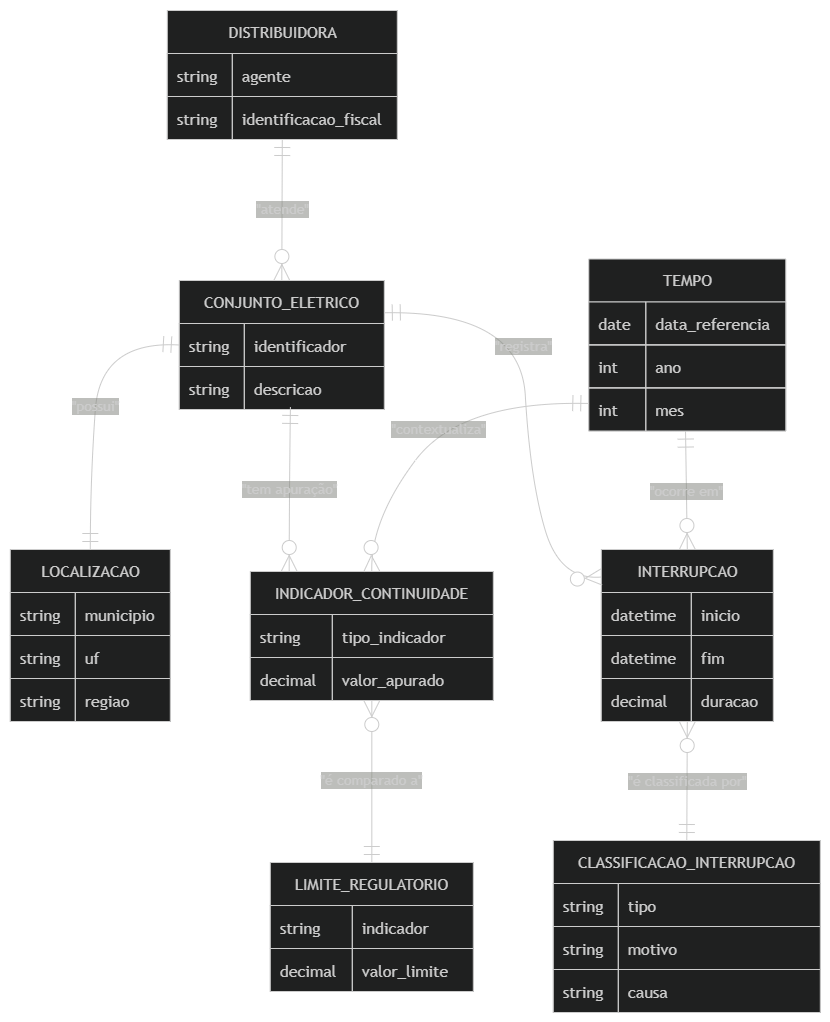

In [126]:
conceptual_model = PROJECT_ROOT / "docs" / "assets" / "conceptual_model.png"

display(
    Image(
        filename=str(conceptual_model),
        width=600
    )
)


---

## 9. Star Schema

O Star Schema é a implementação física do modelo conceitual na camada `data/processed`. Ele organiza o modelo em dimensões e fatos relacionados por chaves primárias e estrangeiras, permitindo análises por tempo, distribuidora, conjunto, indicador, tipo, motivo e causa de interrupção.

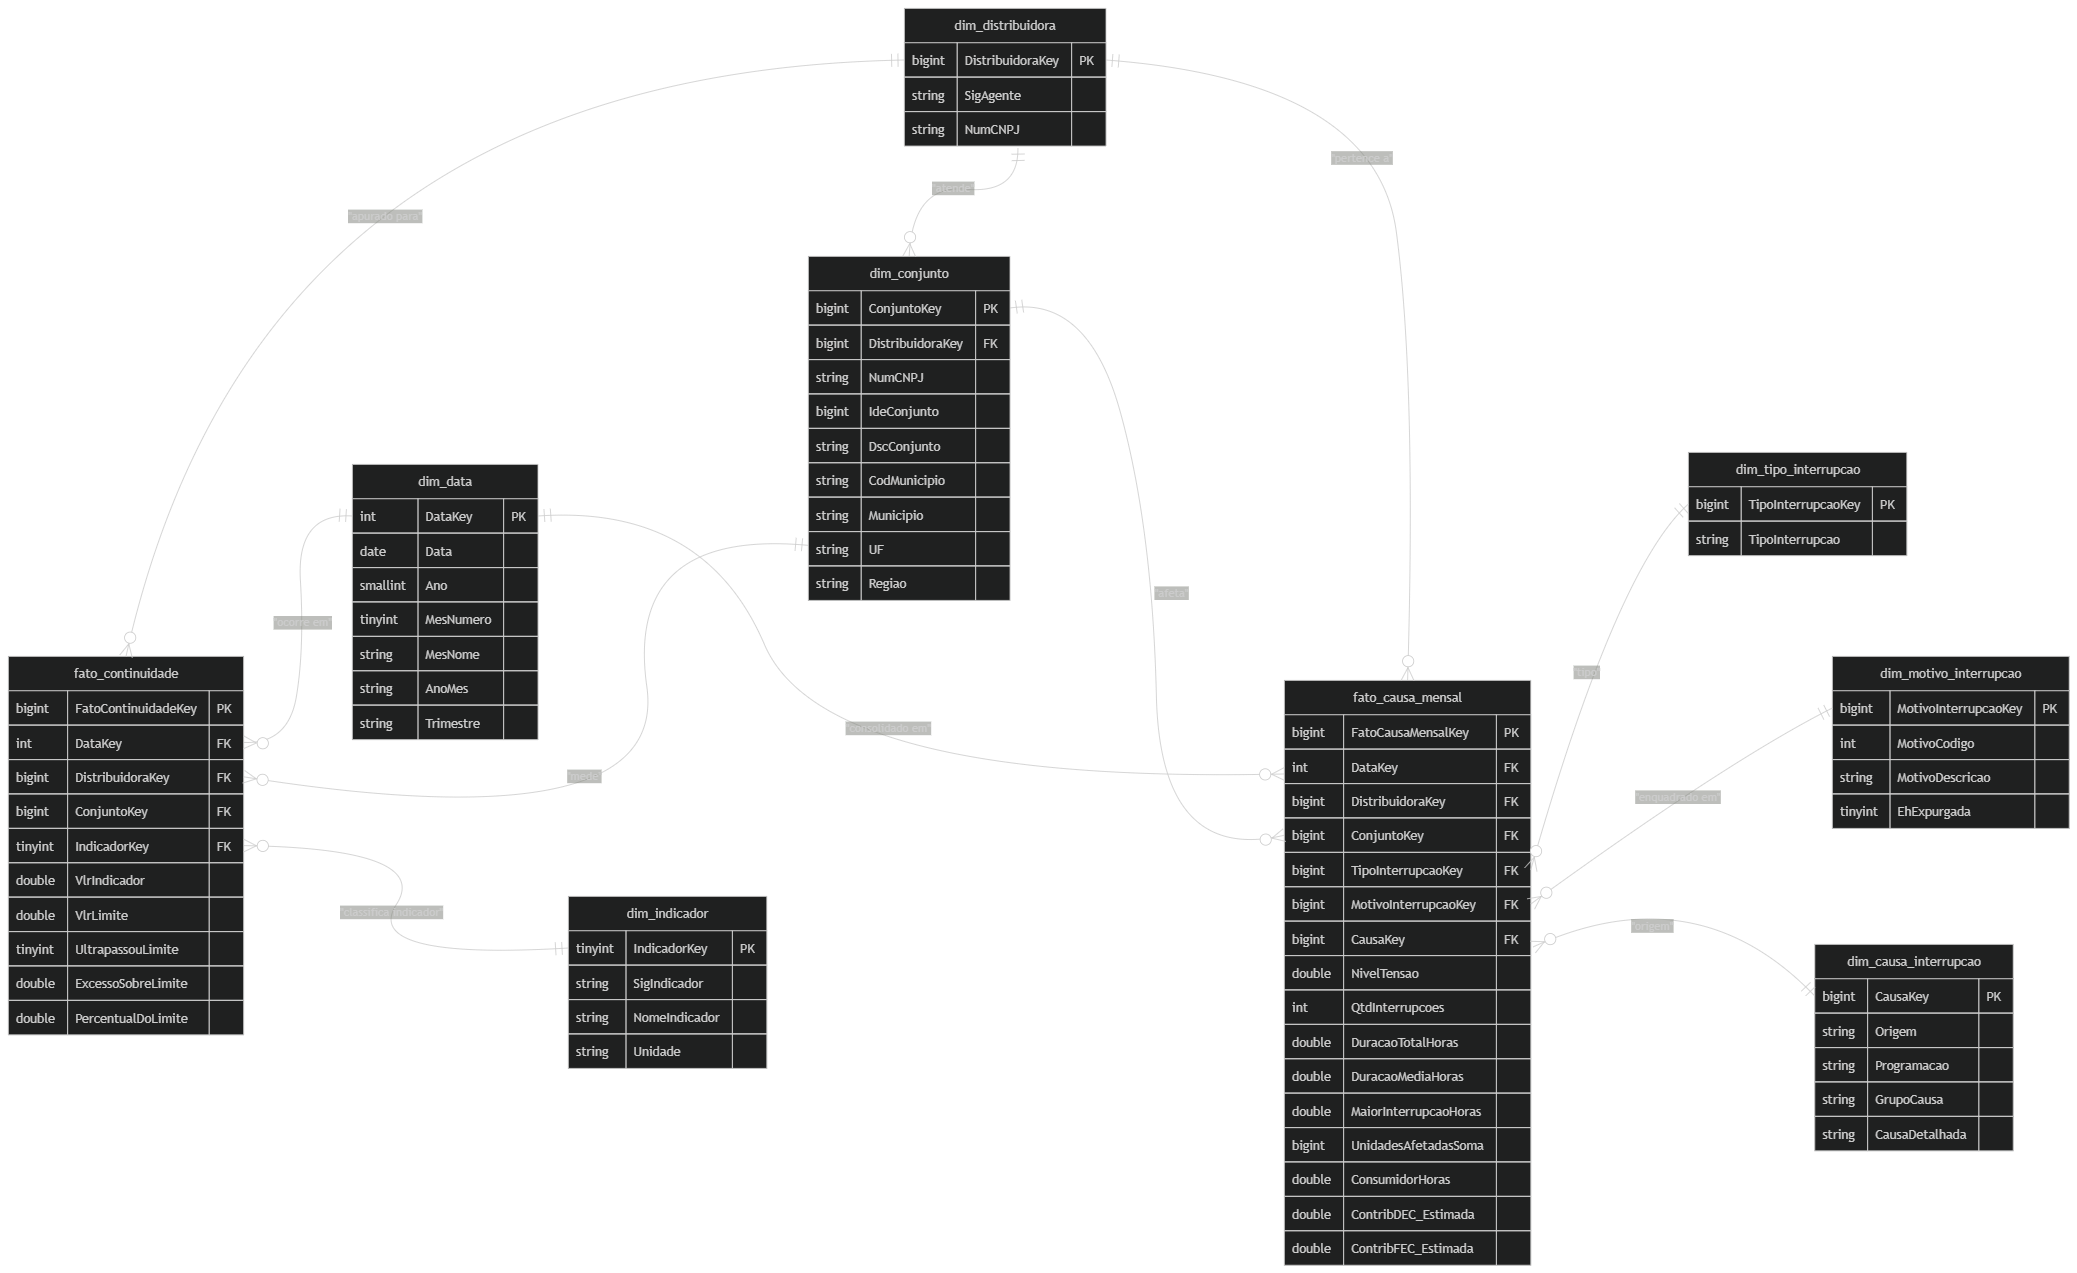

In [127]:
star_schema = PROJECT_ROOT / "docs" / "assets" / "star_schema.png"

display(
    Image(
        filename=str(star_schema),
        width=1500,
    )
)


---

## 10. Dados disponíveis para modelagem


A camada `processed` oferece duas fontes principais para modelagem: `fato_continuidade`, com indicadores DEC/FEC e limites regulatórios, e `fato_causa_mensal`, com características agregadas das interrupções. As dimensões fornecem atributos temporais, geográficos, operacionais e regulatórios para construção das features.

A definição do alvo, a seleção final das variáveis e a preparação dos conjuntos de treino e teste serão realizadas no notebook de preparação de dados. Neste estágio, o objetivo é identificar os dados potencialmente disponíveis para uso.

In [128]:
# Mapeamento dos dados disponíveis para Machine Learning
dados_ml = pd.DataFrame([
    ["fato_continuidade", "Possíveis alvos", "VlrIndicador, UltrapassouLimite, PercentualDoLimite", "Prever ultrapassagem ou risco regulatório"],
    ["fato_continuidade", "Features", "VlrLimite, ExcessoSobreLimite", "Caracterizar a relação entre apuração e limite"],
    ["fato_causa_mensal", "Features", "QtdInterrupcoes, DuracaoTotalHoras, DuracaoMediaHoras, MaiorInterrupcaoHoras", "Representar frequência e duração das interrupções"],
    ["fato_causa_mensal", "Features", "NivelTensao, UnidadesAfetadasSoma, ConsumidorHoras", "Representar impacto operacional"],
    ["fato_causa_mensal", "Features", "ContribDEC_Estimada, ContribFEC_Estimada", "Representar contribuições estimadas aos indicadores"],
    ["dim_data", "Features temporais", "Ano, MesNumero, Trimestre", "Representar sazonalidade e evolução temporal"],
    ["dim_distribuidora", "Features de contexto", "SigAgente, NumCNPJ", "Identificar a distribuidora"],
    ["dim_conjunto", "Features geográficas e cadastrais", "CodMunicipio, Municipio, UF, Regiao", "Representar localização e contexto do conjunto"],
    ["dim_indicador e dimensões de interrupção", "Features categóricas", "SigIndicador, TipoInterrupcao, MotivoDescricao, Origem, GrupoCausa", "Representar categorias operacionais e regulatórias"],
], columns=["origem", "categoria", "colunas_exemplos", "uso_potencial"])

display(
    dados_ml.style.set_properties(
        **{"white-space": "normal", "min-width": "220px"},
    )
)

,origem,categoria,colunas_exemplos,uso_potencial
0,fato_continuidade,Possíveis alvos,"VlrIndicador, UltrapassouLimite, PercentualDoLimite",Prever ultrapassagem ou risco regulatório
1,fato_continuidade,Features,"VlrLimite, ExcessoSobreLimite",Caracterizar a relação entre apuração e limite
2,fato_causa_mensal,Features,"QtdInterrupcoes, DuracaoTotalHoras, DuracaoMediaHoras, MaiorInterrupcaoHoras",Representar frequência e duração das interrupções
3,fato_causa_mensal,Features,"NivelTensao, UnidadesAfetadasSoma, ConsumidorHoras",Representar impacto operacional
4,fato_causa_mensal,Features,"ContribDEC_Estimada, ContribFEC_Estimada",Representar contribuições estimadas aos indicadores
5,dim_data,Features temporais,"Ano, MesNumero, Trimestre",Representar sazonalidade e evolução temporal
6,dim_distribuidora,Features de contexto,"SigAgente, NumCNPJ",Identificar a distribuidora
7,dim_conjunto,Features geográficas e cadastrais,"CodMunicipio, Municipio, UF, Regiao",Representar localização e contexto do conjunto
8,dim_indicador e dimensões de interrupção,Features categóricas,"SigIndicador, TipoInterrupcao, MotivoDescricao, Origem, GrupoCausa",Representar categorias operacionais e regulatórias
